In [1]:
import os
import sys
import tqdm
import json
project_dir = os.path.dirname(os.getcwd())
sys.path.append(project_dir)

from utils.summary import get_model_stats
from utils.plots import plot_training_metrics
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# Data

In [2]:
from data.voc import get_voc_pipeline_test

train_loader, val_loader, test_loader = get_voc_pipeline_test(batch_size=16)
sample_x, sample_y = next(iter(train_loader))
print(sample_x.shape)
print(sample_y.shape)

Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
torch.Size([16, 3, 256, 256])
torch.Size([16, 256, 256])


# Model Stats

In [3]:
from utils.plots import plot_training_metrics
from models.unet import UNet34, UNet18

teacher = UNet34(num_classes=21, pretrained=True).to(device)
student = UNet18(num_classes=21, pretrained=True).to(device)

sample = sample_x.to(device)
with torch.no_grad():
    print("Teacher model stats:")
    pred = teacher(sample)
    pred = student(sample)
    for name, param in get_model_stats(teacher, sample.shape).items():
        print(f"{name}: {param}")
    print("Student model stats:")
    for name, param in get_model_stats(student, sample.shape).items():
        print(f"{name}: {param}")

Teacher model stats:


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)
Unsupported operator aten::add encountered 4 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
encoder.avgpool, encoder.fc
Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)
Unsupported operator aten::add encountered 4 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling m

flops: 98147762176
params: 24233149
Student model stats:
flops: 59440627712
params: 14124989


# Teacher

In [4]:
from utils.losses import MIoU
from utils.train import train_model, evaluate_model


def evaluate_miou(val_loader: DataLoader, model: nn.Module, criterion: nn.Module, device: str='cpu') -> list:
    """
    Evaluate the model on validation data.

    Args:
        model: The PyTorch model to evaluate.
        val_loader: DataLoader for the validation data.
        criterion: Loss function.
        device: Device to run the evaluation on ('cpu' or 'cuda').

    Returns:
        list: Collection of metrics.
    """
    model.eval()
    criterion.reset()
    with torch.no_grad():
        for inputs, targets in tqdm.tqdm(val_loader, desc='evaluating...', file=sys.stdout):
            inputs = inputs.to(device)
            # targets = targets.squeeze(1).long().to(device)
            targets = targets.to(device)
            preds = model(inputs)
            criterion.update(preds, targets)
    miou = criterion.compute()
    return miou


def train_val(train_loader, val_loader, model, optimizer, scheduler, device, path,
              patience=10, epochs=200):
    metrics = {"train_loss": [], "miou": []}
    c1 = nn.CrossEntropyLoss(ignore_index=255)
    c2 = MIoU(num_classes=21, ignore_index=255)
    best_miou = 0
    for epoch in range(epochs):
        train_loss = train_model(train_loader, model, c1, optimizer, scheduler, device)
        miou = evaluate_miou(val_loader, model, c2, device)
        metrics['train_loss'].append(train_loss)
        metrics['miou'].append(miou)
        if metrics['miou'][-1] >= best_miou:
            best_miou = metrics['miou'][-1]
            print(f"Epoch {epoch+1}: New best miou: {best_miou:.4f} saving model...")
            state = {
                'epoch': epoch,
                'state_dict': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'miou': best_miou,
            }
            torch.save(state, path)
    return metrics

evaluating...: 100%|██████████| 91/91 [00:15<00:00,  5.87it/s]
Epoch 1: New best miou: 0.5835 saving model...
evaluating...: 100%|██████████| 91/91 [00:14<00:00,  6.32it/s]
Epoch 2: New best miou: 0.5980 saving model...
evaluating...: 100%|██████████| 91/91 [00:14<00:00,  6.29it/s]
Epoch 3: New best miou: 0.6083 saving model...
evaluating...: 100%|██████████| 91/91 [00:15<00:00,  6.04it/s]
Epoch 6: New best miou: 0.6290 saving model...
evaluating...: 100%|██████████| 91/91 [00:12<00:00,  7.33it/s]
Epoch 9: New best miou: 0.6394 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  6.79it/s]
Epoch 10: New best miou: 0.6484 saving model...
evaluating...: 100%|██████████| 91/91 [00:12<00:00,  7.15it/s]
Epoch 11: New best miou: 0.6544 saving model...
evaluating...: 100%|██████████| 91/91 [00:12<00:00,  7.47it/s]
Epoch 13: New best miou: 0.6632 saving model...
evaluating...: 100%|██████████| 91/91 [00:12<00:00,  7.03it/s]
Epoch 15: New best miou: 0.6696 saving model...
evalua

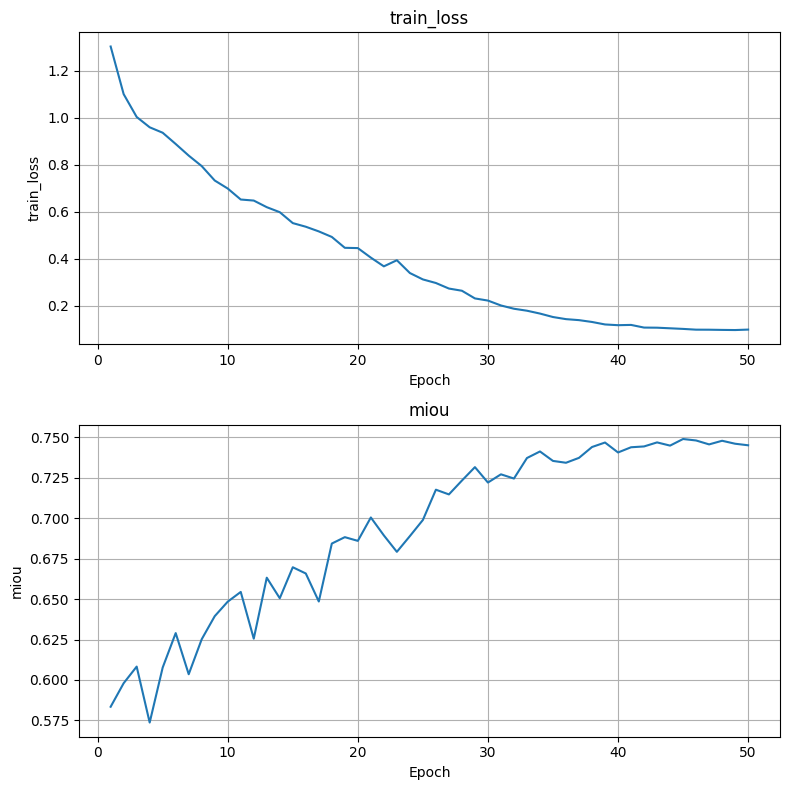

In [5]:
teacher = UNet34(num_classes=21, pretrained=True).to(device)
# optimizer = optim.SGD(teacher.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)
optimizer = optim.Adam(teacher.parameters(), lr=0.0005, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
teacher_path = '../models/weights/voc_unet34_teacher.pth'

metrics_teacher = train_val(train_loader, val_loader, teacher, optimizer, scheduler, device, teacher_path, epochs=50)
for i in range(len(metrics_teacher['miou'])):
    metrics_teacher['miou'][i] = metrics_teacher['miou'][i].item()
plot_training_metrics(metrics_teacher)
with open(os.path.join(project_dir, 'data/states/voc_unet34_teacher.json'), 'w') as f:
    json.dump(metrics_teacher, f)

# Smaller

evaluating...: 100%|██████████| 91/91 [00:14<00:00,  6.08it/s]
Epoch 1: New best miou: 0.5833 saving model...
evaluating...: 100%|██████████| 91/91 [00:15<00:00,  5.93it/s]
Epoch 2: New best miou: 0.5906 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  6.89it/s]
Epoch 5: New best miou: 0.6054 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  6.85it/s]
Epoch 7: New best miou: 0.6135 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  7.00it/s]
Epoch 8: New best miou: 0.6369 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  6.88it/s]
Epoch 9: New best miou: 0.6432 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  6.75it/s]
Epoch 11: New best miou: 0.6477 saving model...
evaluating...: 100%|██████████| 91/91 [00:14<00:00,  6.23it/s]
Epoch 12: New best miou: 0.6506 saving model...
evaluating...: 100%|██████████| 91/91 [00:14<00:00,  6.31it/s]
Epoch 13: New best miou: 0.6524 saving model...
evaluat

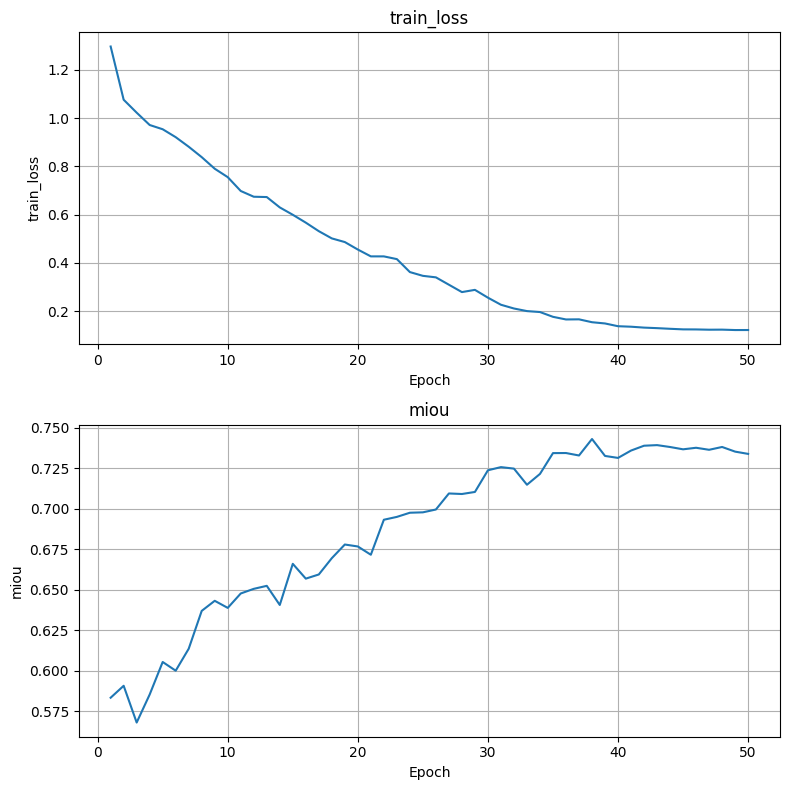

In [7]:
smaller = UNet18(num_classes=21, pretrained=True).to(device)
optimizer = optim.Adam(smaller.parameters(), lr=0.0005, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
smaller_path = '../models/weights/voc_unet18_smaller.pth'

metrics_smaller = train_val(train_loader, val_loader, smaller, optimizer, scheduler, device, smaller_path, epochs=50)
for i in range(len(metrics_smaller['miou'])):
    metrics_smaller['miou'][i] = metrics_smaller['miou'][i].item()
plot_training_metrics(metrics_smaller)
with open(os.path.join(project_dir, 'data/states/voc_unet18_smaller.json'), 'w') as f:
    json.dump(metrics_smaller, f)

# Distill

In [21]:
from utils.distill import distill_model


class DistillationLoss(nn.Module):
    def __init__(self, T=2.0, alpha=0.5, ignore_index=255):
        """
        Distillation loss for semantic segmentation.

        Args:
            T (float): Temperature for softening the probabilities.
            alpha (float): Weighting between the teacher and student losses.
            ignore_index (int): Label value to ignore in the loss calculation.
        """
        super(DistillationLoss, self).__init__()
        self.T = T
        self.alpha = alpha
        self.ignore_index = ignore_index

    def forward(self, student_logits, teacher_logits, labels):
        """
        Forward pass of the distillation loss for segmentation.

        Args:
            student_logits (torch.Tensor): Logits from the student model.
                Shape: (batch_size, num_classes, height, width).
            teacher_logits (torch.Tensor): Logits from the teacher model.
                Shape: (batch_size, num_classes, height, width).
            labels (torch.Tensor): Ground truth labels.
                Shape: (batch_size, height, width).

        Returns:
            torch.Tensor: The distillation loss.
        """
        # Standard cross-entropy loss for segmentation
        cross_entropy_loss = F.cross_entropy(student_logits, labels, ignore_index=self.ignore_index)

        # Create mask for valid pixels (not ignore_index)
        mask = (labels != self.ignore_index).unsqueeze(1)  # Add channel dimension
        
        # Calculate KL divergence loss only on valid pixels
        if mask.sum() > 0:
            # Get softmax with temperature
            student_log_probs = F.log_softmax(student_logits / self.T, dim=1)
            teacher_probs = F.softmax(teacher_logits / self.T, dim=1)
            
            # Apply mask to the tensors
            batch_size, num_classes, H, W = student_logits.size()
            
            # Reshape for easy masking
            student_log_probs_flat = student_log_probs.permute(0, 2, 3, 1).reshape(-1, num_classes)
            teacher_probs_flat = teacher_probs.permute(0, 2, 3, 1).reshape(-1, num_classes)
            mask_flat = mask.permute(0, 2, 3, 1).reshape(-1, 1).squeeze(1)
            
            # Filter out ignored pixels
            student_log_probs_valid = student_log_probs_flat[mask_flat]
            teacher_probs_valid = teacher_probs_flat[mask_flat]
            
            # Calculate KL div on valid pixels only
            kl_loss = F.kl_div(
                student_log_probs_valid,
                teacher_probs_valid,
                reduction='batchmean'
            ) * (self.T * self.T)
        else:
            # No valid pixels, set KL loss to zero
            kl_loss = torch.tensor(0.0, device=student_logits.device)

        # Combine the two losses
        loss = self.alpha * kl_loss + (1 - self.alpha) * cross_entropy_loss
        return loss


def distill_val(train_loader, val_loader, student, teacher, optimizer, scheduler,
                T=3, a=0.5, device='cpu', path='./temp.pth', aux_metrics={}, patience=10, epochs=200):
    metrics = {"train_loss": [], "miou": []}
    c1 = DistillationLoss(T=T, alpha=a, ignore_index=255)
    c2 = MIoU(num_classes=21, ignore_index=255)
    best_miou = 0.
    for epoch in range(epochs):
        train_loss = distill_model(train_loader, student, teacher, c1, optimizer, scheduler, device)
        miou = evaluate_miou(val_loader, student, c2, device)
        metrics['train_loss'].append(train_loss)
        metrics['miou'].append(miou)
        if metrics['miou'][-1] >= best_miou:
            best_miou = metrics['miou'][-1]
            print(f"Epoch {epoch+1}: New best miou: {best_miou:.4f} saving model...")
            state = {
                'epoch': epoch,
                'state_dict': student.state_dict(),
                'optimizer': optimizer.state_dict(),
                'miou': best_miou,
            }
            # state.update({k: metrics[k][-1] for k in metrics.keys()})
            torch.save(state, path)
    return metrics

evaluating...: 100%|██████████| 91/91 [00:14<00:00,  6.27it/s]
Epoch 1: New best miou: 0.5831 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  6.68it/s]
Epoch 2: New best miou: 0.5833 saving model...
evaluating...: 100%|██████████| 91/91 [00:16<00:00,  5.61it/s]
Epoch 3: New best miou: 0.5861 saving model...
evaluating...: 100%|██████████| 91/91 [00:16<00:00,  5.63it/s]
Epoch 4: New best miou: 0.5979 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  6.83it/s]
Epoch 7: New best miou: 0.6019 saving model...
evaluating...: 100%|██████████| 91/91 [00:13<00:00,  6.57it/s]
Epoch 8: New best miou: 0.6021 saving model...
evaluating...: 100%|██████████| 91/91 [00:16<00:00,  5.43it/s]
Epoch 9: New best miou: 0.6236 saving model...
evaluating...: 100%|██████████| 91/91 [00:16<00:00,  5.45it/s]
Epoch 10: New best miou: 0.6274 saving model...
evaluating...: 100%|██████████| 91/91 [00:16<00:00,  5.53it/s]
Epoch 11: New best miou: 0.6277 saving model...
evaluati

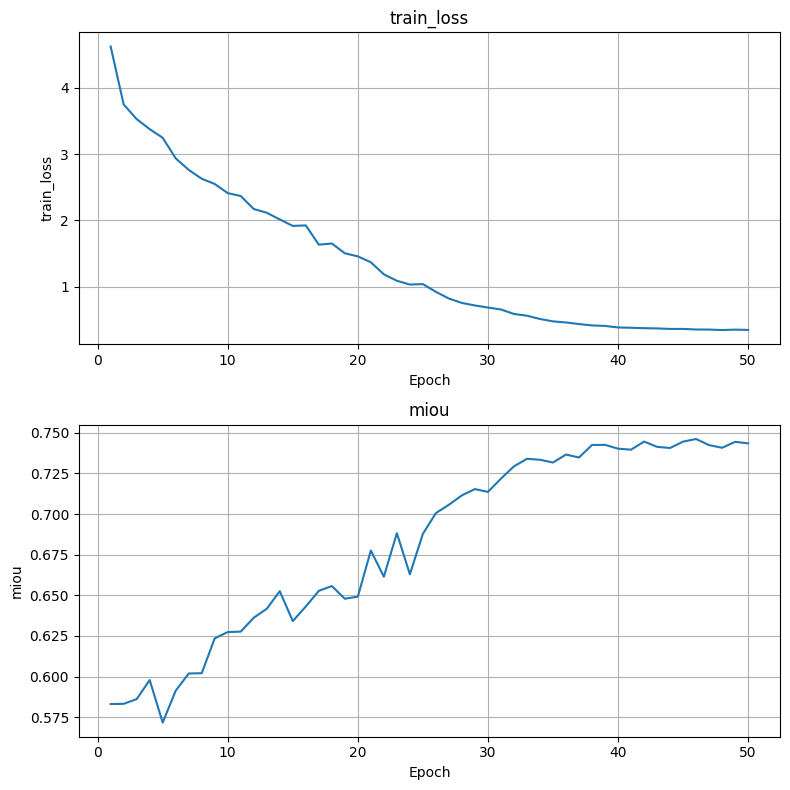

In [22]:
teacher.load_state_dict(torch.load(teacher_path, map_location=device)['state_dict'])
student = UNet18(num_classes=21, pretrained=True).to(device)
optimizer = optim.Adam(student.parameters(), lr=0.0005, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
student_path = '../models/weights/voc_unet18_student.pth'
metrics_student = distill_val(train_loader, val_loader, student, teacher, optimizer, scheduler, 
                              T=4, a=0.3, device=device, path=student_path, patience=50, epochs=50)
for i in range(len(metrics_student['miou'])):
    metrics_student['miou'][i] = metrics_student['miou'][i].item()
with open(os.path.join(project_dir, 'data/states/voc_unet18_student.json'), 'w') as f:
    json.dump(metrics_student, f) 
plot_training_metrics(metrics_student)

# Evaluate

In [23]:
teacher_path = '../models/weights/voc_unet34_teacher.pth'
smaller_path = '../models/weights/voc_unet18_smaller.pth'
student_path = '../models/weights/voc_unet18_student.pth'

teacher_state = torch.load(teacher_path, map_location=device)
smaller_state = torch.load(smaller_path, map_location=device)
student_state = torch.load(student_path, map_location=device)
print(f"Teacher: Val MIoU: {teacher_state['miou']:.4f}")
print(f"Smaller: Val MIoU: {smaller_state['miou']:.4f}")
print(f"Student: Val MIoU: {student_state['miou']:.4f}")

teacher = UNet34(num_classes=21, pretrained=True).to(device)
smaller = UNet18(num_classes=21, pretrained=True).to(device)
student = UNet18(num_classes=21, pretrained=True).to(device)
teacher.load_state_dict(teacher_state['state_dict'])
smaller.load_state_dict(smaller_state['state_dict'])
student.load_state_dict(student_state['state_dict'])

criterion = MIoU()
teacher_test = evaluate_miou(test_loader, teacher, criterion, device)
smaller_test = evaluate_miou(test_loader, smaller, criterion, device)
student_test = evaluate_miou(test_loader, student, criterion, device)
print(f"Teacher: Test MIoU: {teacher_test:.4f}")
print(f"Smaller: Test MIoU: {smaller_test:.4f}")
print(f"Student: Test MIoU: {student_test:.4f}")

Teacher: Val MIoU: 0.7478
Smaller: Val MIoU: 0.7431
Student: Val MIoU: 0.7462
evaluating...: 100%|██████████| 91/91 [00:14<00:00,  6.07it/s]
Teacher: Test MIoU: 0.7480
Smaller: Test MIoU: 0.7364
Student: Test MIoU: 0.7460
